# `vmc_torch` on the GPU: from PEPS to neural tensor networks

`vmc_torch` optimizes a *family* of variational ansätze with a single
Monte Carlo engine. This notebook walks through three members of that
family on one GPU, in increasing order of structure:

| § | Ansatz | System | Tensors |
|---|--------|--------|---------|
| 2 | **Dense PEPS** | 4×4 spin-½ Heisenberg | plain dense arrays |
| 3 | **Fermionic PEPS (fPEPS)** | 4×2 Fermi–Hubbard | Z₂ block-sparse, fermionic |
| 4 | **Neural fTNS** | 4×2 Fermi–Hubbard | fPEPS + a neural network |

The point of the notebook is that **the VMC loop never changes**. It is
written once in §1 and reused verbatim three times. Swapping the ansatz
means swapping the model, the Hamiltonian, the sampler and the
configuration initializer — never the optimizer, the sampler driver, the
energy estimator, or the stochastic-reconfiguration solver.

Each section is validated against exact diagonalization.

**Requirements:** one CUDA GPU. Multi-GPU works too — the same script run
under `torchrun --nproc_per_node=N` distributes walkers across ranks with
no code change (see §6).

## 0. Setup

In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from vmc_torch.GPU.VMC import setup_distributed
from vmc_torch.GPU.hamiltonian import (
    spin_Heisenberg_square_lattice_torch,
    spinful_Fermi_Hubbard_square_lattice_torch,
)
from vmc_torch.GPU.models import (
    WavefunctionModel_GPU,
    fPEPS_Model_GPU,
)
from vmc_torch.GPU.optimizer import IterSRGPU, MinSRGPU
from vmc_torch.GPU.sampler import (
    MetropolisExchangeSpinSamplerGPU,
    MetropolisExchangeSpinfulSamplerGPU,
)
from vmc_torch.GPU.vmc_setup import (
    generate_random_spin_peps,
    initialize_walkers,
    load_or_generate_peps,
    random_spin_config_sz0,
    setup_linalg_hooks,
)
from vmc_torch.GPU.vmc_utils import (
    apply_update,
    broadcast_params,
    compute_grads_gpu,
    evaluate_energy,
    global_energy_stats,
    random_initial_config,
)

# Boundary-MPS contraction needs a *differentiable, degeneracy-safe*
# SVD/QR.  This registers them through autoray, so quimb picks them up
# automatically.  Never rely on bare torch.linalg.svd here.
setup_linalg_hooks(jitter=1e-8, qr_via_eigh=True, nonuniform_diag=True)

# Works with or without torchrun: without it we get rank 0 of a
# world of size 1, and every collective below becomes a no-op.
rank, world_size, device = setup_distributed()

dtype = torch.float32          # float32 for TN contraction + SR
torch.set_default_dtype(dtype)
torch.set_default_device(device)
torch.manual_seed(42 + rank)   # per-rank seed -> independent chains

print(f"device={device}  world_size={world_size}  dtype={dtype}")

device=cuda:0  world_size=1  dtype=torch.float32


## 1. The VMC loop — written once, used three times

Every variational Monte Carlo step is the same five operations,
regardless of what $\psi_\theta$ is:

1. **Sample** $x \sim |\psi_\theta(x)|^2$ with a Metropolis sweep.
2. **Local energies** $E_{\mathrm{loc}}(x) = \sum_{x'} H_{xx'}\,\psi_\theta(x')/\psi_\theta(x)$, shape `(B,)`.
3. **Log-derivatives** $O_k(x) = \partial \log\psi_\theta(x)/\partial\theta_k$, shape `(B, Np)`.
4. **Preconditioned direction** — plain gradient, or SR / minSR applied to
   $\langle O^\dagger E\rangle - \langle O\rangle^\dagger\langle E\rangle$.
5. **Update** $\theta \leftarrow \theta - \eta\,\delta\theta$.

Steps 1–5 are ansatz-agnostic because every model implements the
`WavefunctionModel_GPU` interface (a single-sample `amplitude` /
`log_amplitude`, auto-`vmap`ped to batches) and every solver implements
`PreconditionerGPU.solve`. So we write the loop once.  (The quoted
error bars are the naive $\sqrt{\mathrm{Var}[E_{\mathrm{loc}}]/N_s}$,
neglecting Markov-chain autocorrelation.)

In [ ]:
def run_vmc(model, H, sampler, init_fn, preconditioner, *,
            n_steps, batch_size, lr, burn_in=20, label='',
            ashift=5e-4, rshift=0.0, log_every=20, compile=False):
    """Optimize any WavefunctionModel_GPU by VMC. Returns E/site history.

    Nothing in this function knows which ansatz it is optimizing.

    Args:
        model:  a WavefunctionModel_GPU (dense PEPS, fPEPS, NN-fTNS, ...)
        H:      Hamiltonian with precompute_hops_gpu() already called
        sampler: a *SamplerGPU matching the Hilbert space of H
        init_fn: seed -> (N_sites,) int64 starting configuration
        preconditioner: TrivialPreconditionerGPU / IterSRGPU / MinSRGPU
        n_steps: int, number of VMC steps to run
        batch_size: int, number of walkers per rank
        lr: float, learning rate for the optimizer
        burn_in: int, number of MCMC sweeps to burn in the walkers
        ashift:  float, absolute diagonal shift for Quantum Geometric Tensor (QGT)
        rshift:  float, relative diagonal shift for QGT
        label: str, label for printing/logging
    """
    n_sites = H.graph.n_nodes
    n_params = sum(p.numel() for p in model.parameters())
    broadcast_params(model)          # all ranks start from the same theta

    # One Markov chain per walker, `batch_size` of them per rank.
    fxs = initialize_walkers(
        init_fn=init_fn, batch_size=batch_size,
        seed=42, rank=rank, device=device,
    )
    if compile:
        # optionally compile the model for faster model forward pass.
        print(f"  [{label}] rank {rank} | Compiling model...")
        example_fx = fxs[0]
        model.export_and_compile(
            example_fx,
            use_log_amp=True,
            mode = 'default',
        )
    print(f"  [{label}] rank {rank} | Model burn-in with {fxs.shape[0]} walkers...")
    fxs = sampler.burn_in(fxs, model, H.graph, burn_in, use_log_amp=True)

    history, t_start = [], time.time()
    for step in range(n_steps):
        # 1. MCMC sweep -> new configs and their amplitudes.
        with torch.inference_mode():
            fxs, amps = sampler.step(fxs, model, H.graph, use_log_amp=True)

            # 2. Local energies, shape (B,).
            _, E_loc = evaluate_energy(fxs, model, H, amps,
                                       use_log_amp=True)

        # 3. Per-sample log-derivatives O_loc, shape (B, Np).
        with torch.enable_grad():
            O_loc, _ = compute_grads_gpu(fxs, model,
                                         batch_size=batch_size,
                                         use_log_amp=True)

        # 4. Energy statistics, reduced over all ranks.
        total_ns, e_mean, e_var = global_energy_stats(E_loc, world_size)

        # 5. Update direction (the all_reduce happens inside solve),
        #    then theta <- theta - lr * dp.
        dp, _, _ = preconditioner.solve(
            O_loc=O_loc, E_loc=E_loc, E_mean=e_mean,
            Ns=total_ns, Np=n_params,
            rshift=rshift, ashift=ashift, device=device,
        )
        apply_update(model, torch.as_tensor(dp, device=device), lr)
        broadcast_params(model)      # keep replicas bit-identical

        history.append(e_mean / n_sites)
        if rank == 0 and (step % log_every == 0 or step == n_steps - 1):
            err = np.sqrt(max(e_var, 0.0) / total_ns) / n_sites
            print(f"  [{label}] step {step:3d} | "
                  f"E/site = {e_mean / n_sites:+.6f} +/- {err:.6f}")

    if rank == 0:
        print(f"  [{label}] Np={n_params} | "
              f"{time.time() - t_start:.0f}s total")
    return history

## 2. Dense PEPS — spin-½ Heisenberg

The first ansatz is a plain **projected entangled pair state (PEPS)** on a
4×4 square lattice: one rank-5 tensor per site, dense (no symmetry, no
block structure), physical dimension 2.

$$\psi_\theta(x) \;=\; \mathrm{contract}\Big(\bigotimes_{i} T^{[i]}_{\theta}\big[x_i\big]\Big)$$

The learnable parameters *are* the site tensors. Evaluating an amplitude
means projecting every physical index onto the sampled spin $x_i$
(`isel`) and contracting the resulting 2D network.

We define the model explicitly rather than importing it, so the whole
ansatz is visible. `quimb`'s `pack`/`unpack` round-trips the tensors
between a flat list (what `torch` optimizes) and the structured network
(what we contract); the base class supplies the `vmap` batching.

In [5]:
class PEPS_Model_GPU(WavefunctionModel_GPU):
    """Dense PEPS wavefunction psi_theta(x).

    The amplitude of a configuration x is computed by
      1. projecting every site's physical index onto x[i]  (isel),
      2. contracting the 2D network by boundary-MPS from both ends
         toward the middle, truncating the boundary bond to chi
         (chi <= 0 -> exact contraction, no truncation),
      3. reading off the remaining scalar.
    """

    def __init__(self, tn, max_bond, dtype=torch.float64,
                 contract_boundary_opts=None):
        import quimb as qu
        import quimb.tensor as qtn

        # Split the network into numeric params + a structural skeleton.
        params, skeleton = qtn.pack(tn)
        self.dtype = dtype
        self.skeleton = skeleton
        self.contract_boundary_opts = contract_boundary_opts or {}
        self.chi = max_bond

        # Flatten the param pytree to a flat list for torch, keeping the
        # pytree reference so the forward pass can rebuild the network.
        params_flat, self.params_pytree = qu.utils.tree_flatten(
            params, get_ref=True,
        )
        super().__init__(params_list=[
            torch.as_tensor(x, dtype=dtype) for x in params_flat
        ])

    def _amp_tn(self, x, params):
        """Rebuild the network and project it onto configuration x."""
        import quimb.tensor as qtn

        tn = qtn.unpack(params, self.skeleton)
        amp = tn.isel({
            tn.site_ind(site): x[i] for i, site in enumerate(tn.sites)
        })
        if self.chi > 0:
            # Boundary-MPS sweep inward from both edges.
            amp.contract_boundary_from_xmin_(
                max_bond=self.chi, cutoff=0.0,
                xrange=[0, amp.Lx // 2 - 1], **self.contract_boundary_opts)
            amp.contract_boundary_from_xmax_(
                max_bond=self.chi, cutoff=0.0,
                xrange=[amp.Lx // 2, amp.Lx - 1],
                **self.contract_boundary_opts)
        return amp

    def amplitude(self, x, params):
        """Single config x (N_sites,) int64 -> scalar amplitude psi(x)."""
        return self._amp_tn(x, params).contract()

    def log_amplitude(self, x, params):
        """Single config x -> (sign, log|psi(x)|).

        strip_exponent keeps the contraction in log-space, which avoids
        under/overflow once the lattice is large.
        """
        sign, exponent_10 = self._amp_tn(x, params).contract(
            strip_exponent=True)
        return sign, exponent_10 * torch.log(torch.tensor(10.0))

    def _vamp_params_preprocess(self, params):
        """nn.ParameterList -> quimb param pytree (inverse of __init__)."""
        import quimb as qu

        if isinstance(params, nn.ParameterList):
            params = list(params)
        return qu.utils.tree_unflatten(params, self.params_pytree)

In [6]:
# ---- system ----------------------------------------------------
Lx_s, Ly_s = 4, 4
J = 1.0
N_sites_s = Lx_s * Ly_s
D_s = 4          # PEPS bond dimension
chi_s = -1       # boundary-MPS bond; <= 0 means exact contraction

H_heis = spin_Heisenberg_square_lattice_torch(
    Lx_s, Ly_s, J=J, total_sz=0)
H_heis.precompute_hops_gpu(device)   # GPU-batched get_conn

# ---- exact diagonalization reference ----------------------------
import scipy.sparse.linalg as sla

ed_heis = sla.eigsh(H_heis.to_dense(), k=1, which='SA', tol=1e-9)[0][0]
print(f"ED  E/site = {ed_heis / N_sites_s:.6f} "
      f"(Hilbert space {H_heis.hilbert.size})")

# ---- ansatz -----------------------------------------------------
peps = generate_random_spin_peps(Lx_s, Ly_s, D_s, seed=42, dtype=dtype)
model_peps = PEPS_Model_GPU(
    tn=peps, max_bond=chi_s, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps', 'equalize_norms': 1.0, 'canonize': True},
).to(device)

# ---- optimize ---------------------------------------------------
hist_peps = run_vmc(
    model_peps, H_heis,
    sampler=MetropolisExchangeSpinSamplerGPU(),
    init_fn=lambda seed: random_spin_config_sz0(N_sites_s, seed=seed),
    preconditioner=IterSRGPU(rtol=1e-4, maxiter=100),
    n_steps=40, batch_size=256, lr=0.2, label='PEPS',
    log_every=5
)
rel_peps = abs(np.mean(hist_peps[-20:]) - ed_heis / N_sites_s) \
    / abs(ed_heis / N_sites_s)
print(f"\nfinal E/site = {np.mean(hist_peps[-20:]):+.6f}   "
      f"ED = {ed_heis / N_sites_s:+.6f}   rel. error = {rel_peps:.2%}")

ED  E/site = -0.574325 (Hilbert space 12870)
  [PEPS] rank 0 | Model burn-in with 256 walkers...
  [PEPS] step   0 | E/site = -0.006855 +/- 0.008129
  [PEPS] step   5 | E/site = -0.141153 +/- 0.008888
  [PEPS] step  10 | E/site = -0.441011 +/- 0.011078
  [PEPS] step  15 | E/site = -0.531236 +/- 0.002445
  [PEPS] step  20 | E/site = -0.546191 +/- 0.006302
  [PEPS] step  25 | E/site = -0.552792 +/- 0.002079
  [PEPS] step  30 | E/site = -0.555871 +/- 0.003204
  [PEPS] step  35 | E/site = -0.563225 +/- 0.001939
  [PEPS] step  39 | E/site = -0.561487 +/- 0.002662
  [PEPS] Np=3200 | 17s total

final E/site = -0.556581   ED = -0.574325   rel. error = 3.09%


## 3. Fermionic PEPS — the Fermi–Hubbard model

Now the same thing for **fermions**. The Hubbard Hamiltonian

$$H = -t\sum_{\langle ij\rangle,\sigma}\big(c^{\dagger}_{i\sigma}c_{j\sigma} + \mathrm{h.c.}\big) + U\sum_i n_{i\uparrow}n_{i\downarrow}$$

needs an ansatz that tracks fermionic anticommutation. In `vmc_torch`
that is an **fPEPS**: the same PEPS geometry, but each tensor is a
`symmray` **Z₂-graded block-sparse array**. Fermionic signs are handled
by the tensor algebra itself, not by a Jordan–Wigner string bolted on
afterwards.

Relative to §2, **five lines change** and nothing else:

| §2 — spins | §3 — fermions |
|---|---|
| `generate_random_spin_peps` | `load_or_generate_peps` |
| `PEPS_Model_GPU` (defined above) | `fPEPS_Model_GPU` (library) |
| `spin_Heisenberg_square_lattice_torch` | `spinful_Fermi_Hubbard_square_lattice_torch` |
| `MetropolisExchangeSpinSamplerGPU` | `MetropolisExchangeSpinfulSamplerGPU` |
| `random_spin_config_sz0` | `random_initial_config` |

The local Hilbert space is now 4-dimensional, encoded as
`0 = empty, 1 = up, 2 = down, 3 = doubly occupied`. The
exact-diagonalization reference below is the ground state within the
same $(N_\uparrow, N_\downarrow) = (3, 3)$ sector that the sampler
works in.

We start from a **random** Z₂ fPEPS — no simple-update warm start — so
the whole optimization is visible from scratch. That is what
`random_init=True` requests, and it is why the cells below print
`Could not load Z2-fPEPS from pickle ... Generating random Z2-fPEPS
instead.`; the notice is expected, not an error.

In [ ]:
# ---- system ----------------------------------------------------
Lx_f, Ly_f = 4, 2
t_hop, U_int = 1.0, 8.0
N_sites_f = Lx_f * Ly_f
N_f = 6                       # total fermions (2 holes off half filling)
D_f = 4                       # >= physical dimension 4
chi_f = -1                    # exact contraction

H_hub = spinful_Fermi_Hubbard_square_lattice_torch(
    Lx_f, Ly_f, t_hop, U_int, N_f, pbc=False,
    n_fermions_per_spin=(N_f // 2, N_f // 2),
    no_u1_symmetry=False, gpu=True,
)
# prepare the GPU-batched get_conn() for the Hamiltonian
H_hub.precompute_hops_gpu(device)

# ---- exact diagonalization reference ----------------------------
ed_hub = sla.eigsh(H_hub.to_dense(), k=1, which='SA', tol=1e-9)[0][0]
print(f"ED  E/site = {ed_hub / N_sites_f:.6f} "
      f"(Hilbert space {H_hub.hilbert.size})")

# ---- ansatz -----------------------------------------------------
# random_init=True builds a random Z2 fPEPS instead of loading a
# simple-update warm start from disk; the notice below is expected.
fpeps = load_or_generate_peps(
    Lx_f, Ly_f, t_hop, U_int, N_f, D_f,
    seed=42, dtype=dtype, random_init=True,
)
model_fpeps = fPEPS_Model_GPU(
    tn=fpeps, max_bond=chi_f, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps', 'equalize_norms': 1.0, 'canonize': True},
).to(device)

# ---- optimize ---------------------------------------------------
hist_fpeps = run_vmc(
    model_fpeps, H_hub,
    sampler=MetropolisExchangeSpinfulSamplerGPU(),
    init_fn=lambda seed: random_initial_config(N_f, N_sites_f, seed=seed),
    preconditioner=IterSRGPU(),
    ashift=0.0, rshift=1e-6,
    n_steps=80, batch_size=512, lr=0.2, label='fPEPS',
    log_every=20
)
rel_fpeps = abs(np.mean(hist_fpeps[-20:]) - ed_hub / N_sites_f) \
    / abs(ed_hub / N_sites_f)
print(f"\nfinal E/site = {np.mean(hist_fpeps[-20:]):+.6f}   "
      f"ED = {ed_hub / N_sites_f:+.6f}   rel. error = {rel_fpeps:.2%}")

ED  E/site = -0.718758 (Hilbert space 3136)
Could not load Z2-fPEPS from pickle: random_init=True: skipping loading from disk.. Generating random Z2-fPEPS instead.
  [fPEPS] rank 0 | Model burn-in with 512 walkers...
  [fPEPS] step   0 | E/site = +1.175818 +/- 0.036034
  [fPEPS] step  20 | E/site = -0.616944 +/- 0.004016
  [fPEPS] step  40 | E/site = -0.667542 +/- 0.005085
  [fPEPS] step  60 | E/site = -0.678005 +/- 0.005149
  [fPEPS] step  79 | E/site = -0.693816 +/- 0.003205
  [fPEPS] Np=640 | 65s total

final E/site = -0.691142   ED = -0.718758   rel. error = 3.84%


### What makes the tensors fermionic

The site tensors are not dense arrays. Each is a `symmray` Z₂-graded
array storing only the blocks whose combined charge is allowed — the
even/odd grading *is* fermion parity, and reordering legs during
contraction produces the anticommutation signs automatically.

In [8]:
site = fpeps[fpeps.site_tag(0, 0)].data
print(site)
print(f"\ndense would be {np.prod(site.shape)} entries; "
      f"stored in {site.num_blocks} symmetry blocks")

Z2FermionicArrayFlat(ndim=3, charge=0, indices=[
    (4 = 2 x 2 : +)
    (4 = 2 x 2 : +)
    (4 = 2 x 2 : +)
], num_blocks=4, backend=numpy, dtype=float32)

dense would be 64 entries; stored in 4 symmetry blocks


## 4. Neural fermionic tensor network state

A tensor network with bond dimension $D$ has a fixed, finite amount of
expressive power. A **neural fTNS** lifts that ceiling by letting the
tensor entries themselves depend on the sampled configuration:

$$T^{[i]}(x) \;=\; T^{[i]} \;+\; \eta\, f_\phi(x)^{[i]}$$

where $f_\phi$ is an ordinary neural network. The variational parameters
are the tensors $T$ *and* the network weights $\phi$, optimized jointly.
When $\eta \to 0$ the ansatz reduces exactly to the fPEPS of §3.

Two properties make this well behaved:

- **Symmetry is preserved by construction.** The correction is added to
  the *existing block data* of the Z₂ arrays, so charge sectors are
  untouched — the network cannot break fermion parity.
- **The VMC loop is unchanged.** `SimpleNNfTNS` implements the same
  `amplitude` / `log_amplitude` interface, so `run_vmc` accepts it as-is.

Below is a deliberately minimal version — a two-layer MLP reading the
one-hot configuration — written out in full so the construction is
transparent. The same construction admits arbitrarily more
sophisticated backbones (e.g. transformers); see Ref. [1].

In [ ]:
class SimpleNNfTNS(WavefunctionModel_GPU):
    """fPEPS whose tensor entries carry a config-dependent correction.

        T(x) = T + eta * f_phi(x)

    Parameters are the fPEPS tensors *and* the network weights, held in
    one flat list: entries [:n_ftn] are the tensor network, [n_ftn:] are
    the neural network.

    Args:
        tn:         a Z2 fPEPS (as returned by load_or_generate_peps)
        max_bond:   boundary-MPS bond chi (<= 0 -> exact contraction)
        nn_eta:     overall weight of the network correction
        hidden_dim: width of the MLP hidden layer
        init_scale: scale of the output layer at initialization; small
                    values start the ansatz arbitrarily close to `tn`
    """

    def __init__(self, tn, max_bond, nn_eta=1.0, hidden_dim=64,
                 init_scale=1e-2, dtype=torch.float64,
                 contract_boundary_opts=None):
        import quimb as qu
        import quimb.tensor as qtn
        from vmc_torch.GPU.models import strip_phys_linearmap

        tn = tn.copy()
        self.contract_boundary_opts = contract_boundary_opts or {}

        # The fPEPS physical index carries a `_linearmap` recording
        # where each local state lives in the block-sparse storage.  The
        # library helper trades it for an explicit permutation (derived,
        # not hardcoded) so a sampled configuration value indexes the
        # physical leg directly -- the same bookkeeping fPEPS_Model_GPU
        # does.
        self._loc_basis_perm = strip_phys_linearmap(tn)

        params, skeleton = qtn.pack(tn)
        self.dtype = dtype
        self.skeleton = skeleton
        self.chi = max_bond
        self.nn_eta = nn_eta

        params_flat, self.params_pytree = qu.utils.tree_flatten(
            params, get_ref=True)
        tn_tensors = [torch.as_tensor(x, dtype=dtype)
                      for x in params_flat]

        # Shapes needed to scatter the network output back onto the
        # tensor network.
        self.n_ftn = len(tn_tensors)
        self._tn_shapes = [tuple(p.shape) for p in tn_tensors]
        self._tn_sizes = [p.numel() for p in tn_tensors]

        self.n_sites = tn.num_tensors
        net = nn.Sequential(
            nn.Linear(4 * self.n_sites, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, sum(self._tn_sizes)),
        ).to(dtype)
        with torch.no_grad():
            net[-1].weight.mul_(init_scale)
            net[-1].bias.zero_()

        # Keep the network's tensors in self.params (so the optimizer
        # sees exactly one copy) and drive the module functionally.
        # object.__setattr__ bypasses nn.Module registration, which
        # would otherwise count these parameters a second time.
        nn_names, nn_tensors = zip(*net.named_parameters())
        object.__setattr__(self, '_net', net)
        self._nn_names = list(nn_names)

        super().__init__(params_list=tn_tensors + list(nn_tensors))

    def _corrected_tn_params(self, x, params_list):
        """Tensor-network params with the correction for config x added."""
        import quimb as qu

        tn_flat = params_list[:self.n_ftn]
        nn_flat = params_list[self.n_ftn:]

        # One-hot the configuration -> (4 * N_sites,) feature vector.
        feat = F.one_hot(x, 4).reshape(-1).to(self.dtype)
        delta = torch.func.functional_call(
            self._net, dict(zip(self._nn_names, nn_flat)), (feat,))

        # Scatter the flat output back onto the tensor shapes.
        corrected = [
            p + self.nn_eta * d.view(s)
            for p, d, s in zip(tn_flat,
                               torch.split(delta, self._tn_sizes),
                               self._tn_shapes)
        ]
        return qu.utils.tree_unflatten(corrected, self.params_pytree)

    def _amp_tn(self, x, params_list):
        import quimb.tensor as qtn

        tn = qtn.unpack(self._corrected_tn_params(x, params_list),
                        self.skeleton)
        if self._loc_basis_perm is not None:
            x = self._loc_basis_perm[x]
        amp = tn.isel({
            tn.site_ind(site): x[i] for i, site in enumerate(tn.sites)
        })
        if self.chi > 0:
            amp.contract_boundary_from_xmin_(
                max_bond=self.chi, cutoff=0.0,
                xrange=[0, amp.Lx // 2 - 1], **self.contract_boundary_opts)
            amp.contract_boundary_from_xmax_(
                max_bond=self.chi, cutoff=0.0,
                xrange=[amp.Lx // 2, amp.Lx - 1],
                **self.contract_boundary_opts)
        return amp

    def amplitude(self, x, params_list):
        return self._amp_tn(x, params_list).contract()

    def log_amplitude(self, x, params_list):
        sign, exponent_10 = self._amp_tn(x, params_list).contract(
            strip_exponent=True)
        return sign, exponent_10 * torch.log(torch.tensor(10.0))

    def _vamp_params_preprocess(self, params):
        # The tensor/network split happens inside amplitude(), so the
        # flat list is passed straight through.
        if isinstance(params, nn.ParameterList):
            return list(params)
        return params

**Sanity check first.** At `init_scale = 0` the network output is
identically zero, so the ansatz must reproduce the §3 fPEPS *exactly*.
This also confirms the parameter bookkeeping: `Np` should be the tensor
count plus the network count, with nothing double-registered.

In [10]:
_check = SimpleNNfTNS(
    tn=fpeps, max_bond=chi_f, nn_eta=1.0, hidden_dim=64,
    init_scale=0.0, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps', 'equalize_norms': 1.0, 'canonize': True},
).to(device)

# The plain fPEPS at its *initial* parameters, for comparison.  Both
# models are built from the same `fpeps` object: constructing a model
# leaves the source network untouched.
_ref = fPEPS_Model_GPU(
    tn=fpeps, max_bond=chi_f, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps', 'equalize_norms': 1.0, 'canonize': True},
).to(device)

_x = initialize_walkers(
    init_fn=lambda seed: random_initial_config(N_f, N_sites_f, seed=seed),
    batch_size=64, seed=1, rank=0, device=device)
with torch.inference_mode():
    s_ref, l_ref = _ref.forward_log(_x)
    s_nn, l_nn = _check.forward_log(_x)

n_tn_params = sum(p.numel() for p in _ref.parameters())
n_all_params = sum(p.numel() for p in _check.parameters())
print(f"max |log|psi| difference| = {(l_ref - l_nn).abs().max():.3e}")
print(f"signs identical           = {bool((s_ref == s_nn).all())}")
print(f"Np: {n_tn_params} (tensors) + "
      f"{n_all_params - n_tn_params} (network) = {n_all_params}")

max |log|psi| difference| = 0.000e+00
signs identical           = True
Np: 640 (tensors) + 43712 (network) = 44352


In [15]:
model_nnftns = SimpleNNfTNS(
    tn=fpeps, max_bond=chi_f,
    nn_eta=1.0, hidden_dim=64, init_scale=1e-2, dtype=dtype,
    contract_boundary_opts={
        'mode': 'mps', 'equalize_norms': 1.0, 'canonize': True},
).to(device)

# With Np >> Ns the Ns-form solver is the cheaper one: minSR solves an
# Ns x Ns Gram system instead of the Np x Np quantum geometric tensor.
# Swapping the preconditioner is the only change to the call.
hist_nnftns = run_vmc(
    model_nnftns, H_hub,
    sampler=MetropolisExchangeSpinfulSamplerGPU(),
    init_fn=lambda seed: random_initial_config(N_f, N_sites_f, seed=seed),
    preconditioner=MinSRGPU(),
    ashift=0.0, rshift=1e-6,
    n_steps=80, batch_size=512, lr=0.2, label='NN-fTNS',
    log_every=10
)
rel_nnftns = abs(np.mean(hist_nnftns[-20:]) - ed_hub / N_sites_f) \
    / abs(ed_hub / N_sites_f)
print(f"\nfinal E/site = {np.mean(hist_nnftns[-20:]):+.6f}   "
      f"ED = {ed_hub / N_sites_f:+.6f}   rel. error = {rel_nnftns:.2%}")

  [NN-fTNS] rank 0 | Model burn-in with 512 walkers...
  [NN-fTNS] step   0 | E/site = +1.160417 +/- 0.036401
  [NN-fTNS] step  10 | E/site = -0.576235 +/- 0.009051
  [NN-fTNS] step  20 | E/site = -0.623502 +/- 0.019034
  [NN-fTNS] step  30 | E/site = -0.640862 +/- 0.006795
  [NN-fTNS] step  40 | E/site = -0.661913 +/- 0.010508
  [NN-fTNS] step  50 | E/site = -0.676388 +/- 0.011463
  [NN-fTNS] step  60 | E/site = -0.688801 +/- 0.006257
  [NN-fTNS] step  70 | E/site = -0.683888 +/- 0.006838
  [NN-fTNS] step  79 | E/site = -0.690328 +/- 0.007986
  [NN-fTNS] Np=44352 | 71s total

final E/site = -0.685771   ED = -0.718758   rel. error = 4.59%


## 5. Summary

VMC optimization energy curves for the above three tensor-network ansätze.

In this tutorial, for NN-fPEPS we only used very simple neural networks and very short optimization runs, thus the energy does not show clear improvement over pure fPEPS. In practice, one would use a more expressive network and longer runs to see the benefits of the neuralization.

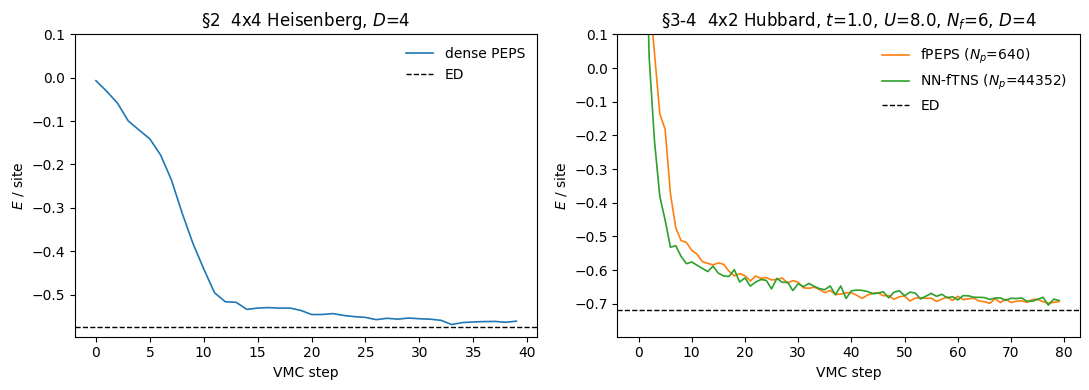

ansatz      system                  Np      E/site          ED   rel.err
PEPS        4x4 Heisenberg        3200   -0.556581   -0.574325    3.09%
fPEPS       4x2 Hubbard            640   -0.691142   -0.718758    3.84%
NN-fPEPS    4x2 Hubbard          44352   -0.685771   -0.718758    4.59%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(hist_peps, lw=1.2, color='C0', label='dense PEPS')
ax.axhline(ed_heis / N_sites_s, ls='--', c='k', lw=1, label='ED')
ax.set_title(f'$\\S$2  {Lx_s}x{Ly_s} Heisenberg, $D$={D_s}')
ax.set_xlabel('VMC step'); ax.set_ylabel('$E$ / site')
ax.legend(frameon=False); ax.set_ylim(top=0.1)

ax = axes[1]
ax.plot(hist_fpeps, lw=1.2, color='C1',
        label=f'fPEPS ($N_p$={sum(p.numel() for p in model_fpeps.parameters())})')
ax.plot(hist_nnftns, lw=1.2, color='C2',
        label=f'NN-fTNS ($N_p$={sum(p.numel() for p in model_nnftns.parameters())})')
ax.axhline(ed_hub / N_sites_f, ls='--', c='k', lw=1, label='ED')
ax.set_title(f'$\\S$3-4  {Lx_f}x{Ly_f} Hubbard, $t$={t_hop}, $U$={U_int}, '
             f'$N_f$={N_f}, $D$={D_f}')
ax.set_xlabel('VMC step'); ax.set_ylabel('$E$ / site')
ax.legend(frameon=False); ax.set_ylim(top=0.1)

fig.tight_layout()
plt.show()

print(f"{'ansatz':<12}{'system':<18}{'Np':>8}{'E/site':>12}"
      f"{'ED':>12}{'rel.err':>10}")
for name, sysname, m, h, ed, ns in [
    ('PEPS', f'{Lx_s}x{Ly_s} Heisenberg', model_peps, hist_peps,
     ed_heis, N_sites_s),
    ('fPEPS', f'{Lx_f}x{Ly_f} Hubbard', model_fpeps, hist_fpeps,
     ed_hub, N_sites_f),
    ('NN-fPEPS', f'{Lx_f}x{Ly_f} Hubbard', model_nnftns, hist_nnftns,
     ed_hub, N_sites_f),
]:
    e = np.mean(h[-20:])
    print(f"{name:<12}{sysname:<18}"
          f"{sum(p.numel() for p in m.parameters()):>8}"
          f"{e:>12.6f}{ed / ns:>12.6f}"
          f"{abs(e - ed / ns) / abs(ed / ns):>9.2%}")

These are short demonstration runs on small lattices — enough to show
each ansatz optimizing from a random start and approaching the exact
answer, not a converged benchmark.

## 6. Scaling up

Everything above ran on one GPU with exact contraction. The knobs that
matter beyond toy sizes:

- **Multiple GPUs.** Save this notebook as a script and launch it with
  `torchrun --nproc_per_node=N script.py`. Walkers are distributed across
  ranks; `global_energy_stats` and `preconditioner.solve` already carry
  the `all_reduce`s, so no code changes.
- **Larger lattices.** Set `chi > 0` to switch from exact contraction to
  a truncated boundary-MPS environment. Cost then scales polynomially in
  `chi` rather than exponentially in the lattice width.
- **Compilation.** `model.export_and_compile(example_x)` traces the
  `quimb` contraction into a pure-ATen FX graph and fuses it with
  `torch.compile` (plain `torch.compile` cannot trace `quimb` directly).
  `forward` / `forward_log` / `compute_grads_gpu` then dispatch to the
  compiled path automatically.
- **Environment reuse.** The `*Reuse_GPU` models and samplers cache
  boundary-MPS environments between Metropolis moves, which is the main
  structural speedup for large PEPS.
- **CPU clusters.** The MPI code path (`examples/vmc_run_example.py`)
  distributes sampling over thousands of cores via `mpi4py`.

### References

[1] S.-J. Du, A. Chen, G. K.-L. Chan, *Neuralized fermionic tensor
networks for quantum many-body systems*,
[Phys. Rev. B **113**, 085134](https://doi.org/10.1103/x8vl-qf14)

[2] W.-Y. Liu, S.-J. Du, R. Peng, J. Gray, G. K.-L. Chan, *Tensor network
computations that capture strict variationality, volume law behavior,
and the efficient representation of neural network states*,
[Phys. Rev. Lett. **133**, 260404](https://doi.org/10.1103/PhysRevLett.133.260404)